### Análise de transações financeiras

## Busines Problem

Este projeto tem como objetivo analisar transações financeiras
para entender padrões de receita e despesas, identificar
principais categorias de gastos e analisar o comportamento
ao longo do tempo.

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Criando Dataset pedi para o chat criar
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "data": pd.date_range(start="2022-01-01", periods=n, freq="H"),
    "categoria": np.random.choice(
        ["Alimentação","Transporte","Lazer","Saúde","Educação","Moradia","Salário"],
        n
    ),
    "tipo": np.random.choice(
        ["Receita","Despesa"],
        n,
        p=[0.3,0.7]
    ),
    "valor": np.random.randint(20, 5000, n),
    "regiao": np.random.choice(
        ["Sul","Sudeste","Nordeste","Centro-Oeste","Norte"],
        n
    )
})

df.head()

/tmp/ipykernel_5035/2528392194.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "data": pd.date_range(start="2022-01-01", periods=n, freq="H"),


,data,categoria,tipo,valor,regiao
0,2022-01-01 00:00:00,Salário,Despesa,1269,Norte
1,2022-01-01 01:00:00,Saúde,Despesa,4788,Sudeste
2,2022-01-01 02:00:00,Educação,Despesa,650,Centro-Oeste
3,2022-01-01 03:00:00,Salário,Receita,681,Centro-Oeste
4,2022-01-01 04:00:00,Lazer,Despesa,3523,Sul


### Dataset Visão geral

In [29]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       1000 non-null   datetime64[ns]
 1   categoria  1000 non-null   object        
 2   tipo       1000 non-null   object        
 3   valor      1000 non-null   int64         
 4   regiao     1000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 39.2+ KB


### Limpeza e preparação do dataset

In [30]:
df.isnull().sum()

df["data"] = pd.to_datetime(df["data"])

df["mes"] = df["data"].dt.month
df["ano"] = df["data"].dt.year
df["dia_semana"] = df["data"].dt.day_name()

### Análise exploratória

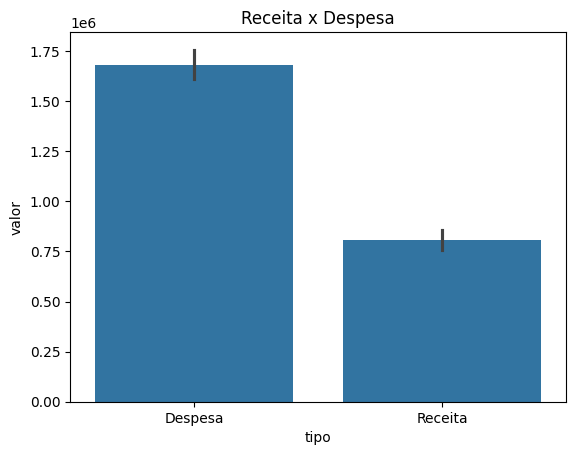

In [31]:
sns.barplot(data=df, x="tipo", y="valor", estimator=sum)

plt.title("Receita x Despesa")
plt.show()

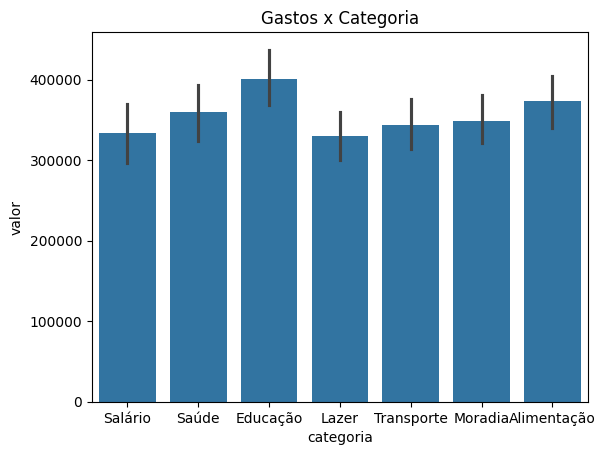

In [32]:
sns.barplot(data=df, x="categoria", y="valor", estimator=sum)

plt.xticks(rotation=0)
plt.title("Gastos x Categoria")
plt.show()

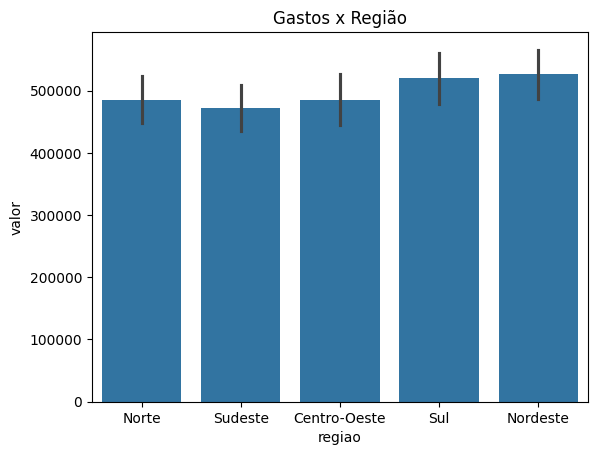

In [33]:
sns.barplot(data=df, x="regiao", y="valor", estimator=sum)

plt.xticks(rotation=0)
plt.title("Gastos x Região")
plt.show()

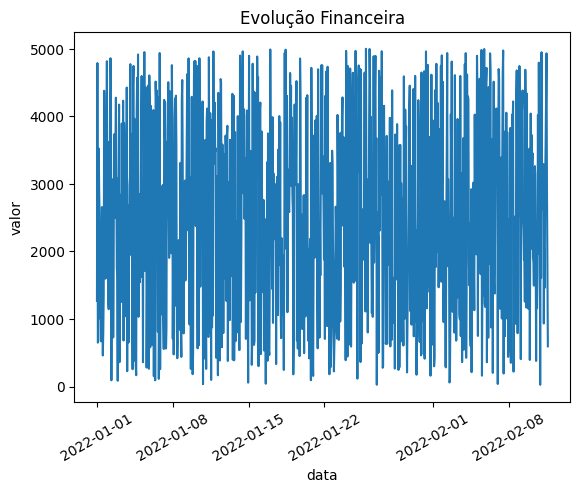

In [40]:
df_time = df.groupby("data")["valor"].sum().reset_index()

sns.lineplot(data=df_time, x="data", y="valor")

plt.xticks(rotation=30)
plt.title("Evolução Financeira")
plt.show()

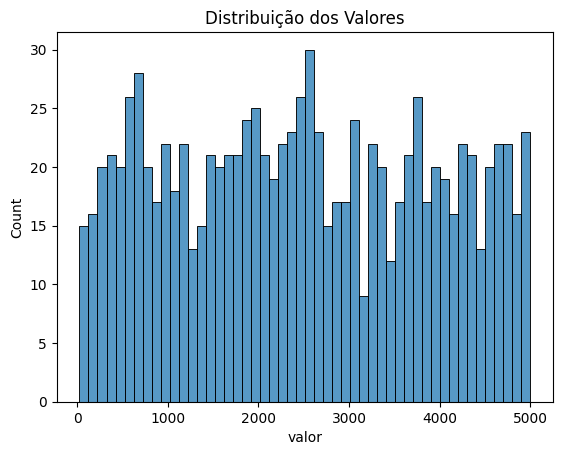

In [46]:
sns.histplot(df["valor"], bins=50)

plt.title("Distribuição dos Valores")
plt.show()

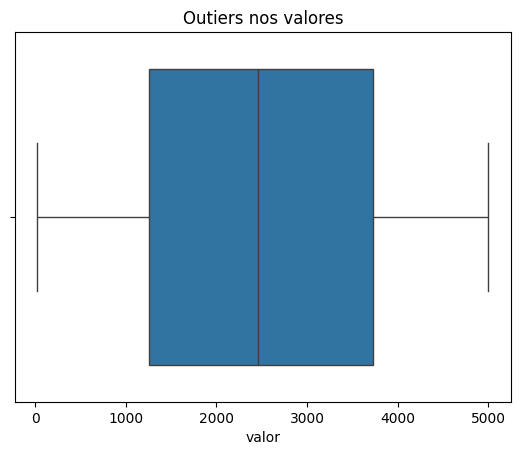

In [48]:
sns.boxplot(x=df["valor"])

plt.title("Outiers nos valores")
plt.show()

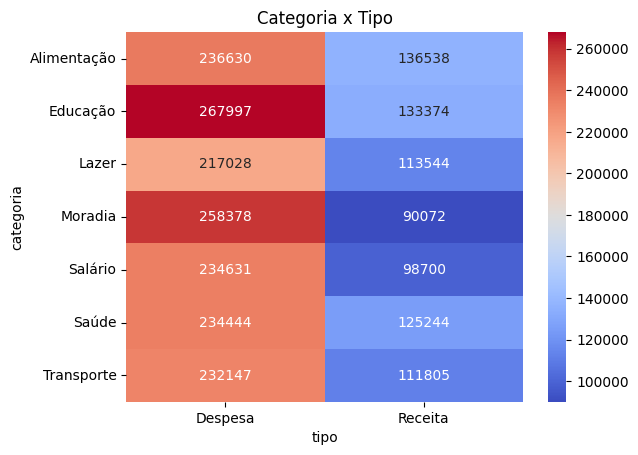

In [52]:
pivot = df.pivot_table(
    values= "valor",
    index= "categoria",
    columns= "tipo",
    aggfunc= "sum"
)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("Categoria x Tipo")
plt.show()

### Insights

*   Despesas representam a maior parte das transações
*   Categoria Moradia concentra alto volume financeiro
*   Receitas possuem maior valor médio
*   Existem picos de movimentação ao longo do tempo

### Recomendações

*   Reduzir gastos nas categorias mais recorrentes
*   Monitorar períodos de maior despesa
*   Buscar equilíbrio entre receita e despesa